<a href="https://colab.research.google.com/github/Wafik20/SOTA-deep-learning-code-samples/blob/main/pemdiv_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The 1D Case

Each prediction is a number and an index in 1D space

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import LinearSegmentedColormap, Normalize

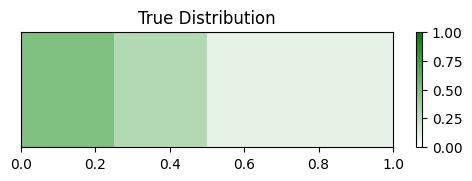

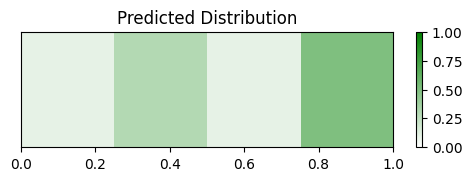

In [ ]:
preds = [0.1, 0.3, 0.1, 0.5]
true = [0.5, 0.3, 0.1, 0.1]

assert np.isclose(np.sum(true), 1) and np.isclose(np.sum(preds), 1)

# Create white → green colormap
white_green = LinearSegmentedColormap.from_list(
    "white_green",
    ["white", "green"]
)

vmin = 0
vmax = 1

# ---- True Distribution ----
plt.figure(figsize=(6, 1.5))
plt.imshow([true], aspect='auto', cmap=white_green, vmin=vmin, vmax=vmax, extent=(0, 1, 0, 1))
plt.title("True Distribution")
plt.yticks([])
plt.colorbar()
plt.show()

# ---- Predicted Distribution ----
plt.figure(figsize=(6, 1.5))
plt.imshow([preds], aspect='auto', cmap=white_green, vmin=vmin, vmax=vmax, extent=(0, 1, 0, 1))
plt.title("Predicted Distribution")
plt.yticks([])
plt.colorbar()
plt.show()

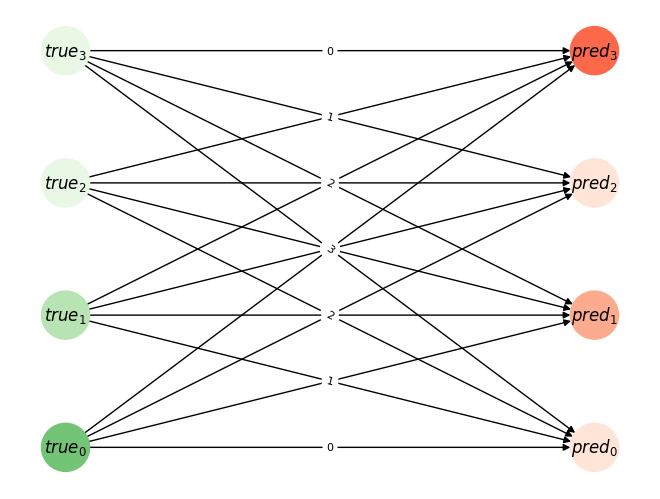

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def create_simple_network_from_pair_1d_dist(preds, true):
    G = nx.DiGraph()

    # Add left nodes (true distribution) → green
    for i in range(len(true)):
        G.add_node(f"$true_{i}$", prob=true[i], bipartite=0)

    # Add right nodes (pred distribution) → red
    for j in range(len(preds)):
        G.add_node(f"$pred_{j}$", prob=preds[j], bipartite=1)

    # Fully connect: green → red
    for i in range(len(true)):
        for j in range(len(preds)):
            weight = abs(i - j)
            G.add_edge(f"$true_{i}$", f"$pred_{j}$", weight=weight)

    return G

G = create_simple_network_from_pair_1d_dist(preds, true)

# ---- Bipartite layout ----
left_nodes = [n for n, d in G.nodes(data=True) if d["bipartite"] == 0]
right_nodes = [n for n, d in G.nodes(data=True) if d["bipartite"] == 1]

pos = {}
pos.update({n: (0, i) for i, n in enumerate(left_nodes)})
pos.update({n: (1, i) for i, n in enumerate(right_nodes)})

# ---- Node coloring (independent red / green) ----
green_cmap = plt.cm.Greens
red_cmap = plt.cm.Reds

green_norm = Normalize(vmin=0, vmax=1)
red_norm = Normalize(vmin=0, vmax=1)

node_colors = []
for n, d in G.nodes(data=True):
    if d["bipartite"] == 0:
        node_colors.append(green_cmap(green_norm(d["prob"])))
    else:
        node_colors.append(red_cmap(red_norm(d["prob"])))

# ---- Draw ----
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=1200,
    arrows=True
)

edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.show()

In [ ]:
def min_cost_transport(true, preds, scale=1000):
    true = np.array(true, dtype=float)
    preds = np.array(preds, dtype=float)

    assert np.isclose(true.sum(), 1)
    assert np.isclose(preds.sum(), 1)

    # Convert to integers
    supply = np.rint(true * scale).astype(int)
    demand = np.rint(preds * scale).astype(int)

    # Fix rounding mismatch
    diff = supply.sum() - demand.sum()
    if diff > 0:
        demand[np.argmax(preds)] += diff
    elif diff < 0:
        supply[np.argmax(true)] += -diff

    G = nx.DiGraph()

    # Add green supply nodes (negative demand)
    for i, s in enumerate(supply):
        G.add_node(f"a{i}", demand=-int(s))

    # Add red demand nodes (positive demand)
    for j, d in enumerate(demand):
        G.add_node(f"b{j}", demand=int(d))

    # Fully connect green → red
    for i in range(len(true)):
        for j in range(len(preds)):
            G.add_edge(
                f"a{i}",
                f"b{j}",
                weight=abs(i - j),   # cost
                capacity=1 * scale  # effectively 1 in probability space
            )

    flow = nx.min_cost_flow(G)
    cost = nx.cost_of_flow(G, flow)

    return flow, cost / scale  # rescale cost back

flow, cost = min_cost_transport(true, preds)

print("Transport cost:", cost)

Transport cost: 1.2


In [ ]:
def emd_1d(true, preds):
    true = np.asarray(true, dtype=float)
    preds = np.asarray(preds, dtype=float)

    if not np.isclose(true.sum(), 1):
        raise ValueError("`true` must sum to 1")
    if not np.isclose(preds.sum(), 1):
        raise ValueError("`preds` must sum to 1")
    if len(true) != len(preds):
        raise ValueError("Distributions must have same length")

    cdf_true = np.cumsum(true)
    cdf_preds = np.cumsum(preds)

    return np.sum(np.abs(cdf_true - cdf_preds))

print("EMD:", emd_1d(true, preds))

EMD: 1.2000000000000002


## The 2D Case
Each prediction is a number and a position in 2D space

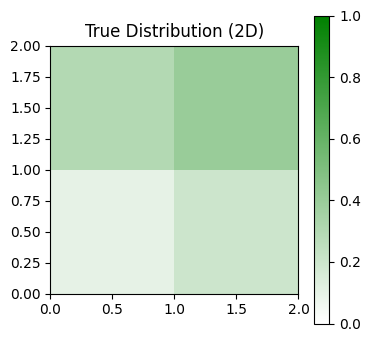

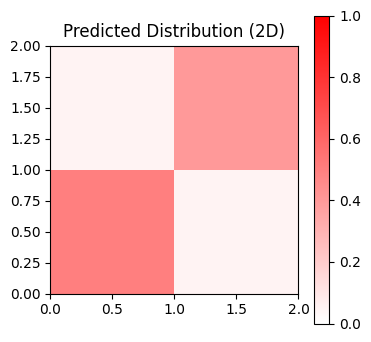

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

true_2d = np.array([
    [0.1, 0.2],
    [0.3, 0.4]
])

preds_2d = np.array([
    [0.5, 0.05],
    [0.05, 0.4]
])

assert np.isclose(true_2d.sum(), 1)
assert np.isclose(preds_2d.sum(), 1)

# White → Green
white_green = LinearSegmentedColormap.from_list(
    "white_green",
    ["white", "green"]
)

# White → Red
white_red = LinearSegmentedColormap.from_list(
    "white_red",
    ["white", "red"]
)

vmin = 0
vmax = 1

# ---- True Distribution ----
plt.figure(figsize=(4, 4))
plt.imshow(
    true_2d,
    cmap=white_green,
    vmin=vmin,
    vmax=vmax,
    extent=(0, true_2d.shape[1], 0, true_2d.shape[0]),
    origin="lower"
)
plt.title("True Distribution (2D)")
plt.colorbar()
plt.show()

# ---- Predicted Distribution ----
plt.figure(figsize=(4, 4))
plt.imshow(
    preds_2d,
    cmap=white_red,
    vmin=vmin,
    vmax=vmax,
    extent=(0, preds_2d.shape[1], 0, preds_2d.shape[0]),
    origin="lower"
)
plt.title("Predicted Distribution (2D)")
plt.colorbar()
plt.show()

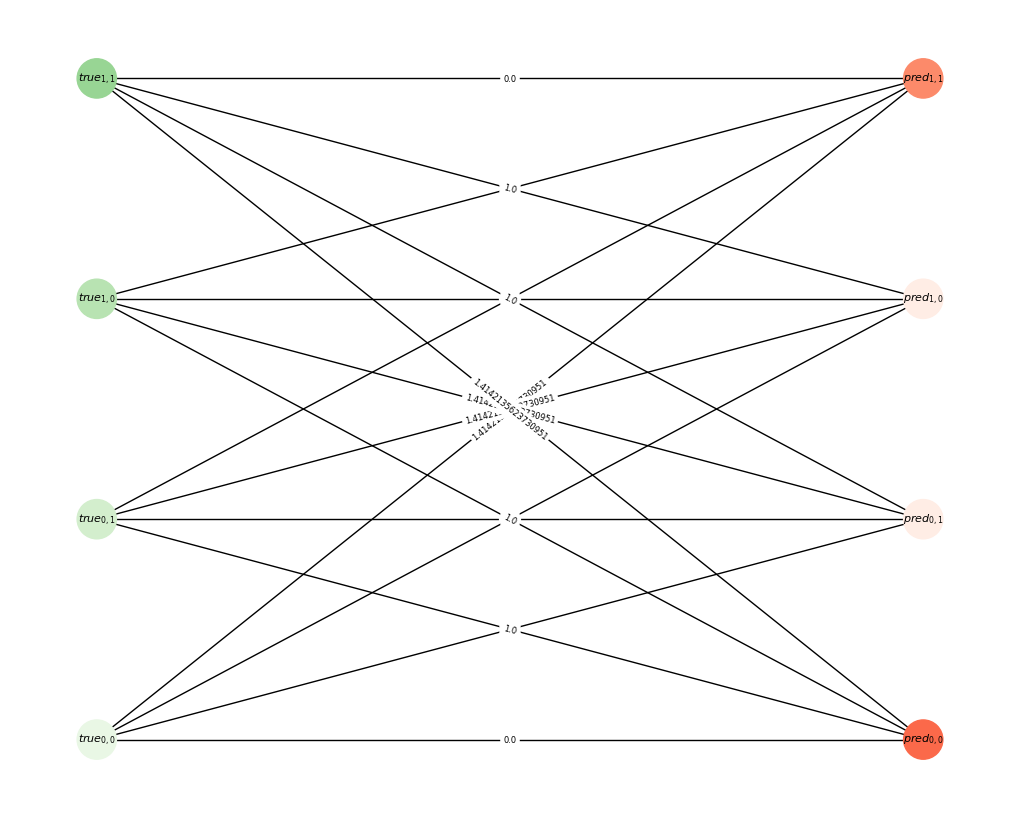

In [ ]:
def create_simple_network_from_pair_2d_dist(preds_2d, true_2d):
    G = nx.DiGraph()

    h, w = true_2d.shape

    # Add green nodes (true distribution)
    for i in range(h):
        for j in range(w):
            G.add_node(
                f"$true_{{{i},{j}}}$",
                prob=true_2d[i, j],
                bipartite=0
            )

    # Add red nodes (pred distribution)
    for i in range(h):
        for j in range(w):
            G.add_node(
                f"$pred_{{{i},{j}}}$",
                prob=preds_2d[i, j],
                bipartite=1
            )

    # Fully connect: true → pred
    for i1 in range(h):
        for j1 in range(w):
            for i2 in range(h):
                for j2 in range(w):

                    weight = np.sqrt(
                        (i2 - i1)**2 + (j2 - j1)**2
                    )

                    G.add_edge(
                        f"$true_{{{i1},{j1}}}$",
                        f"$pred_{{{i2},{j2}}}$",
                        weight=weight
                    )

    return G

G = create_simple_network_from_pair_2d_dist(preds_2d, true_2d)

# ---- Bipartite layout (stacked vertically) ----
left_nodes = [n for n, d in G.nodes(data=True) if d["bipartite"] == 0]
right_nodes = [n for n, d in G.nodes(data=True) if d["bipartite"] == 1]

pos = {}
pos.update({n: (0, i) for i, n in enumerate(left_nodes)})
pos.update({n: (3, i) for i, n in enumerate(right_nodes)})

# ---- Independent coloring ----
green_cmap = plt.cm.Greens
red_cmap = plt.cm.Reds
norm = Normalize(vmin=0, vmax=1)

node_colors = []
for n, d in G.nodes(data=True):
    if d["bipartite"] == 0:
        node_colors.append(green_cmap(norm(d["prob"])))
    else:
        node_colors.append(red_cmap(norm(d["prob"])))

# ---- Draw ----
plt.figure(figsize=(10, 8))

nx.draw(
    G,
    pos,
    with_labels=True,   # ← turn labels on
    node_color=node_colors,
    node_size=800,
    arrows=False,
    font_size=8
)

edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=6
)

plt.show()

## Adding time as a dimension
As a simple exercise, let's consider the case where we're predicting the value of some variable x over the course of t time steps. This can thought of as an array where arr[i] is just the value of x at time step i.

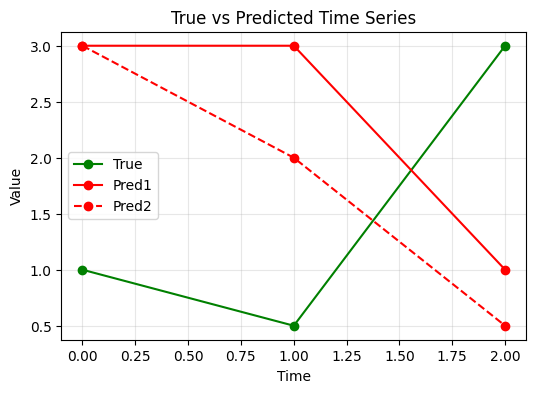

In [ ]:
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt

x_true = [1, 0.5, 3]
x_pred1 = [3, 3, 1]
x_pred2 = [3, 2, 0.5]

t = range(len(x_true))

plt.figure(figsize=(6,4))

plt.plot(t, x_true, marker='o', color='green', label="True")
plt.plot(t, x_pred1, marker='o', color='red', label="Pred1")
plt.plot(t, x_pred2, marker='o', color='red', label="Pred2", linestyle='dashed')


plt.xlabel("Time")
plt.ylabel("Value")
plt.title("True vs Predicted Time Series")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### An interesting question emerges, can you guess which time series predictions is better? pred or pred2?

The graph picture of this timeseries is pretty interesting. Let's model it as a bipartite graph where each node on the left subgraph represents a true value of x at some time step t, and each node on the right subgraph represents a predicted value of x at some time step t. Now, the interesting part is how to think about the weights. In our previous cases, the weight was just the euclidian distance. However, this won't work for the timeseries setting. Simply due to the fact that moving mass between two nodes i, j can conceptually be possible in two cases: 1- i = j, or we're moving mass from i to j and j > i "we can't go back in time".

Let's think about this simple example

true = 1, 2, 3
preds = 3, 3, 1

the first prediction of 3 should be better and hence weighed less in the error than the last prediction of 1, since we did get a three later in time. However, we got 1 at the very beginning

## Let's visualize this

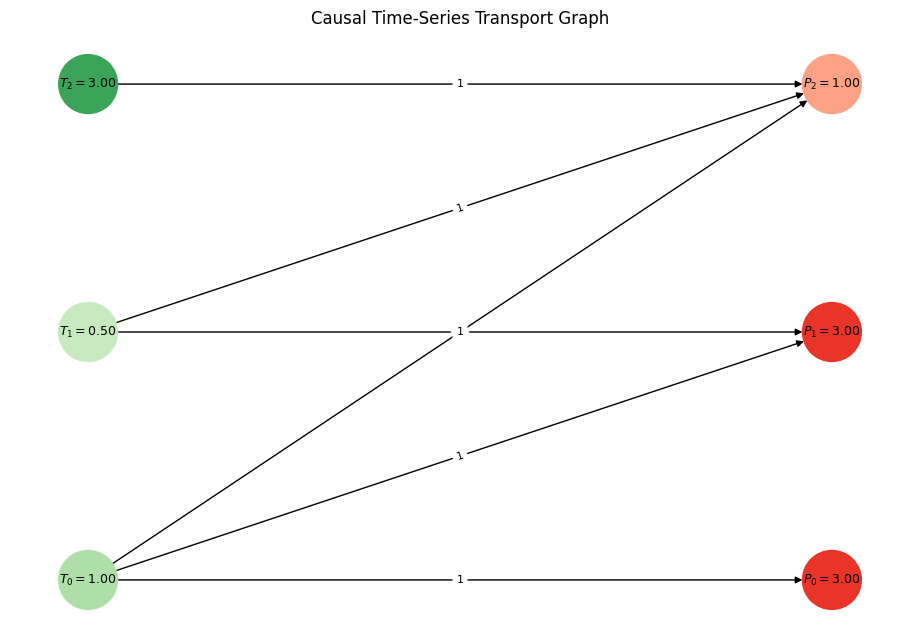

In [ ]:
def create_simple_network_from_pair_time_series(x_preds, x_true):
    G = nx.DiGraph()

    # Normalize ONLY for coloring
    all_vals = np.array(x_true + x_preds)
    norm = Normalize(vmin=all_vals.min(), vmax=all_vals.max())

    # Add true nodes
    for i, val in enumerate(x_true):
        label = f"$T_{{{i}}}={val:.2f}$"
        G.add_node(
            label,
            prob=val,
            color_val=norm(val),
            bipartite=0
        )

    # Add pred nodes
    for j, val in enumerate(x_preds):
        label = f"$P_{{{j}}}={val:.2f}$"
        G.add_node(
            label,
            prob=val,
            color_val=norm(val),
            bipartite=1
        )

    # Connect true → pred (forward in time)
    for i, true_val in enumerate(x_true):
        for j, pred_val in enumerate(x_preds):
            if j >= i:
                weight = 1
                G.add_edge(
                    f"$T_{{{i}}}={true_val:.2f}$",
                    f"$P_{{{j}}}={pred_val:.2f}$",
                    weight=weight
                )

    return G

G = create_simple_network_from_pair_time_series(x_pred1, x_true)

# ---- Bipartite layout ----
left_nodes = [n for n, d in G.nodes(data=True) if d["bipartite"] == 0]
right_nodes = [n for n, d in G.nodes(data=True) if d["bipartite"] == 1]

pos = {}
pos.update({n: (0, i) for i, n in enumerate(left_nodes)})
pos.update({n: (2, i) for i, n in enumerate(right_nodes)})

# ---- Node coloring (SOFT colors) ----
green_cmap = plt.cm.Greens
red_cmap = plt.cm.Reds

node_colors = []
for n, d in G.nodes(data=True):

    # restrict to lighter range
    softened_val = 0.25 + 0.4 * d["color_val"]  # maps into [0.25, 0.65]

    if d["bipartite"] == 0:
        node_colors.append(green_cmap(softened_val))
    else:
        node_colors.append(red_cmap(softened_val))

# ---- Draw graph ----
plt.figure(figsize=(9, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=1800,
    arrows=True,
    font_size=9
)

# ---- Draw edge weights ----
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Causal Time-Series Transport Graph")
plt.axis("off")
plt.show()

Note that regular EMD fails in this case, since the surplus mass is not equal to the deficit mass. In other words, we cannot find a unified normalized representation of the two bins. Approaches like $\hat{\text{EMD}}$ and $\text{pEMDIV}$ fill this gap.

## Putting it all together
Now, let's think about an example where each point is a prediction in 2D spaces over some time horizon $T$. Each prediction will look like a sequence of tuples $(x_1, y_1, val_1), (x_2, y_2, val_2), \ldots, (x_n, y_n, val_n)$. Let's assume we have a grid of $n \times n$.

In [ ]:
import numpy as np

def generate_random_sequence(n, T, smooth=False, decimals=2):
    """
    Generate sequence of (x_t, y_t, v_t) over T steps on n x n grid.
    Values rounded to given decimal precision.
    """

    rng = np.random.default_rng()

    # ---- Spatial coordinates ----
    if smooth:
        x = [int(rng.integers(0, n))]
        y = [int(rng.integers(0, n))]

        for _ in range(T - 1):
            dx = int(rng.choice([-1, 0, 1]))
            dy = int(rng.choice([-1, 0, 1]))

            x_new = max(0, min(n - 1, x[-1] + dx))
            y_new = max(0, min(n - 1, y[-1] + dy))

            x.append(x_new)
            y.append(y_new)
    else:
        x = [int(i) for i in rng.integers(0, n, size=T)]
        y = [int(i) for i in rng.integers(0, n, size=T)]

    # ---- Values ----
    v = rng.random(T)
    v /= v.sum()

    # round
    v = np.round(v, decimals)

    # renormalize after rounding
    v /= v.sum()

    # round again for clean display
    v = np.round(v, decimals)

    v = [float(val) for val in v]

    return list(zip(x, y, v))


# Example
n = 3
T = 3

true_seq = generate_random_sequence(n, T, smooth=True, decimals=2)
pred_seq = generate_random_sequence(n, T, smooth=False, decimals=2)

print("True:", true_seq)
print("Pred:", pred_seq)

True: [(1, 2, 0.49), (2, 1, 0.01), (2, 2, 0.5)]
Pred: [(2, 2, 0.44), (0, 2, 0.48), (0, 2, 0.07)]


In [ ]:
import numpy as np
import networkx as nx
from matplotlib.colors import Normalize

def create_simple_network_from_pair_time_series_2D(x_preds, x_true):

    G = nx.DiGraph()

    # ---- Normalize only for coloring ----
    all_vals = [v for (_, _, v) in x_true] + \
               [v for (_, _, v) in x_preds]

    norm = Normalize(vmin=min(all_vals), vmax=max(all_vals))

    # ---- Add true nodes ----
    for t, (x, y, val) in enumerate(x_true):

        label = f"T{t}({x},{y}):{val:.2f}"

        G.add_node(
            label,
            prob=val,
            color_val=norm(val),
            bipartite=0
        )

    # ---- Add pred nodes ----
    for t, (x, y, val) in enumerate(x_preds):

        label = f"P{t}({x},{y}):{val:.2f}"

        G.add_node(
            label,
            prob=val,
            color_val=norm(val),
            bipartite=1
        )

    # ---- Connect true → pred (causal forward only) ----
    for i, (x1, y1, true_val) in enumerate(x_true):
        for j, (x2, y2, pred_val) in enumerate(x_preds):

            if j >= i:

                edge_weight = np.round(
                    np.sqrt((x2 - x1)**2 + (y2 - y1)**2), 2
                )

                G.add_edge(
                    f"T{i}({x1},{y1}):{true_val:.2f}",
                    f"P{j}({x2},{y2}):{pred_val:.2f}",
                    weight=edge_weight
                )

    return G

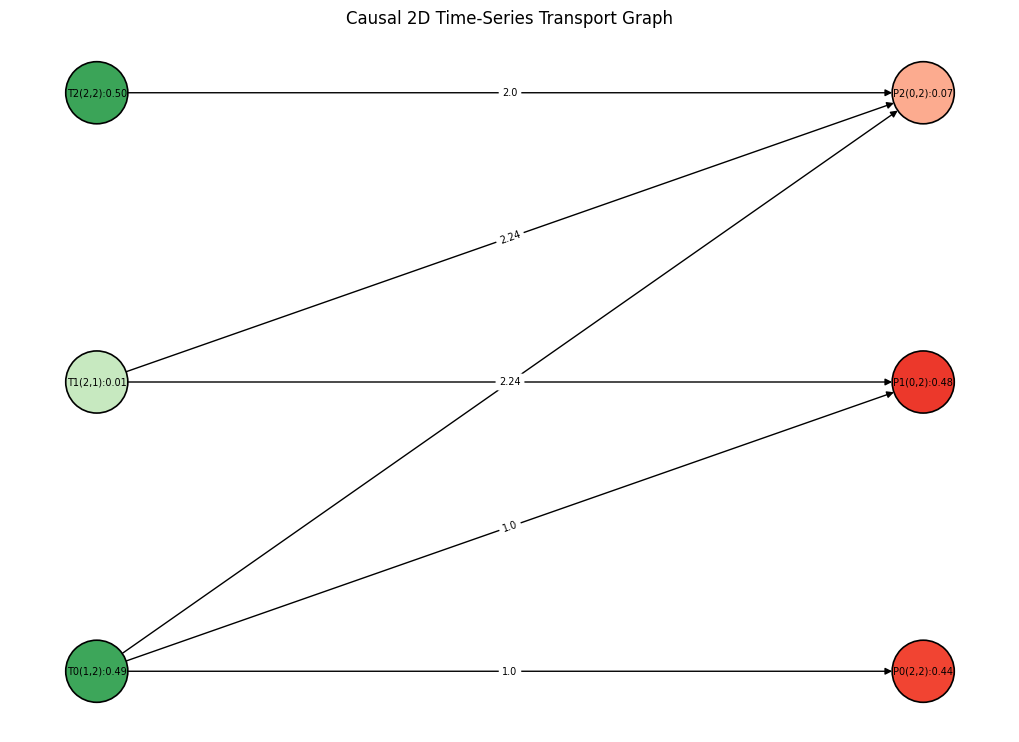

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Create graph
G = create_simple_network_from_pair_time_series_2D(pred_seq, true_seq)

# ---- Bipartite layout ----
left_nodes = [n for n, d in G.nodes(data=True) if d["bipartite"] == 0]
right_nodes = [n for n, d in G.nodes(data=True) if d["bipartite"] == 1]

pos = {}
pos.update({n: (0, i) for i, n in enumerate(left_nodes)})
pos.update({n: (3, i) for i, n in enumerate(right_nodes)})

# ---- Soft node coloring ----
green_cmap = plt.cm.Greens
red_cmap = plt.cm.Reds

node_colors = []
for n, d in G.nodes(data=True):

    softened_val = 0.25 + 0.4 * d["color_val"]  # light pastel range

    if d["bipartite"] == 0:
        node_colors.append(green_cmap(softened_val))
    else:
        node_colors.append(red_cmap(softened_val))

# ---- Draw graph ----
plt.figure(figsize=(10, 7))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2000,
    arrows=True,
    font_size=7,     # smaller text
    edgecolors="black",
    linewidths=1.2
)

# ---- Edge labels ----
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

plt.title("Causal 2D Time-Series Transport Graph")
plt.axis("off")
plt.show()

## Thinking about min cost flow in the matrix formalism

In [ ]:
from scipy.optimize import linprog

preds = [0.1, 0.3, 0.1, 0.5]
true = [0.5, 0.3, 0.1, 0.1]

cost = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        cost[i, j] = np.sqrt((i - j)**2)

c = cost.reshape(-1)
n = 4 # Our array is 4x4, n = m = 4


A_eq = []
b_eq = []

# Row constraints: sum_j gamma[i,j] = preds[i]
for i in range(n):
    row = np.zeros(n ** 2)
    for j in range(n):
        row[i * n + j] = 1
    A_eq.append(row)
    b_eq.append(preds[i])

# Column constraints: sum_i gamma[i,j] = true[j]
for j in range(n):
    col = np.zeros(n ** 2)
    for i in range(n):
        col[i * n + j] = 1
    A_eq.append(col)
    b_eq.append(true[j])

A_eq = np.array(A_eq) # Each row in the array represents an equation. For example,
# \gamma_{00} A_eq[0][0], \gamma_{01} A_eq[0][1], ..., \gamma_{33} A_eq[0][16] = b_eq[0]
b_eq = np.array(b_eq)

print(A_eq)
print(b_eq)

bounds = [(0, None)] * (n ** 2)

res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
gamma = res.x.reshape(n, n)
print(f"optimal transport plan:\n", gamma)
print(f"min cost flow:\n", res.fun)

[[1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1.]]
[0.1 0.3 0.1 0.5 0.5 0.3 0.1 0.1]
optimal transport plan:
 [[ 0.1  0.   0.   0. ]
 [-0.   0.3  0.   0. ]
 [ 0.1  0.   0.   0. ]
 [ 0.3  0.   0.1  0.1]]
min cost flow:
 1.2000000000000002


# Calculating pEMDiv

The regular definition of optimal transport, EMD:

\begin{aligned}
\min_{T \ge 0} \quad & \sum_{i=1}^n \sum_{j=1}^m C_{ij} \, T_{ij} \\
\text{s.t.} \quad
& \sum_{j=1}^m T_{ij} = P_i \quad \forall i = 1,\dots,n, \\
& \sum_{i=1}^n T_{ij} = Q_j \quad \forall j = 1,\dots,m.
\end{aligned}

Now, let's assume our bins do not have equal mass, and we want to charge a cost per unit mass created or destroyed after our transport. pEMDiv is a good way to model this:



\begin{aligned}
\min_{T \ge 0}\quad
& \sum_{i=1}^n \sum_{j=1}^m C_{ij}\,T_{ij}
\;+\;\alpha_d \sum_{i=1}^n \Big(P_i - \sum_{j=1}^m T_{ij}\Big)
\;+\;\alpha_c \sum_{j=1}^m \Big(Q_j - \sum_{i=1}^n T_{ij}\Big)\\
\text{s.t.}\quad
& \sum_{j=1}^m T_{ij} \le P_i \quad \forall i=1,\dots,n,\\
& \sum_{i=1}^n T_{ij} \le Q_j \quad \forall j=1,\dots,m.
\end{aligned}

assuming $a_c = a_d$:


\begin{aligned}
\min_{T\ge 0}\quad
& \sum_{i=1}^n\sum_{j=1}^m C_{ij}\,T_{ij}
+\alpha\Big(\sum_{i=1}^n P_i+\sum_{j=1}^m Q_j-2\sum_{i=1}^n\sum_{j=1}^m T_{ij}\Big)\\
\text{s.t.}\quad
& \sum_{j=1}^m T_{ij}\le P_i \ \forall i,\qquad
  \sum_{i=1}^n T_{ij}\le Q_j \ \forall j
\end{aligned}

Calculating Entropy on $U_i \in U(r, c)$

In [ ]:
U = np.array([
    [0.1, 0,   0,   0],
    [0.3, 0,   0,   0],
    [0.1, 0,   0,   0],
    [0,   0.3, 0.1, 0.1]
])
def U_entropy(U):
  entropy = 0
  w, h = U.shape
  for i in range(w):
    for j in range(h):
      if(U[i][j] != 0):
        entropy -= U[i][j] * np.log2(U[i][j])
  return entropy

print(U_entropy(U))

2.3709505944546683


Calculating KL Divergence for $P, Q \in U(r, c)$

In [ ]:
U1 = np.array([
    [0.1, 0,   0,   0],
    [0.3, 0,   0,   0],
    [0.1, 0,   0,   0],
    [0,   0.3, 0.1, 0.1]
])

U2 = np.array([
    [0.05, 0.05, 0,    0   ],
    [0.25, 0.05, 0,    0   ],
    [0.10, 0,    0,    0   ],
    [0.10, 0.20, 0.10, 0.10]
])

def kl_div_U(U1, U2):
    mask = U1 > 0
    return np.sum(U1[mask] * np.log2(U1[mask] / U2[mask]))

print(kl_div_U(U1, U2))

0.3543990719664849


Estimating min cost flow using Sinkhorn-Knopp Algorithm. [paper](https://arxiv.org/abs/1306.0895)

In [ ]:
preds = [0.1, 0.3, 0.1, 0.5]
true = [0.5, 0.3, 0.1, 0.1]

cost = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        cost[i, j] = np.sqrt((i - j)**2)

def sinkhorn_knopp_min_cost_flow(M, lam, r, c, tol=1e-9, max_iter=10000):
    """
    Entropic OT via Sinkhorn-Knopp scaling.

    M  : cost matrix (d x d)
    lam: regularization strength (lambda in paper)
    r  : source distribution (length d)
    c  : target distribution (length d)
    """

    M = np.array(M, dtype=float)
    r = np.array(r, dtype=float)
    c = np.array(c, dtype=float)

    # Normalize just in case
    r = r / r.sum()
    c = c / c.sum()

    # Gibbs kernel
    K = np.exp(-lam * M)

    # Initialize scaling vectors
    u = np.ones_like(r)
    v = np.ones_like(c)

    for _ in range(max_iter):
        u_prev = u.copy()

        # Update scaling
        u = r / (K @ v)
        v = c / (K.T @ u)

        # Check convergence
        if np.linalg.norm(u - u_prev, 1) < tol:
            break

    # Transport plan
    P = np.diag(u) @ K @ np.diag(v)

    # Regularized transport cost
    cost = np.sum(P * M)

    return P, cost

P, reg_cost = sinkhorn_knopp_min_cost_flow(cost, lam=10, r=preds, c=true)

print("Transport plan:\n", P)
print("Row sums:", P.sum(axis=1))
print("Col sums:", P.sum(axis=0))
print("Regularized cost:", reg_cost)

Transport plan:
 [[9.99999998e-02 1.54586521e-10 1.85865498e-19 4.78871681e-28]
 [1.71428571e-01 1.28571428e-01 1.54586521e-10 3.98283211e-19]
 [4.57142857e-02 3.42857143e-02 2.00000000e-02 5.15288405e-11]
 [1.82857143e-01 1.37142857e-01 7.99999999e-02 9.99999999e-02]]
Row sums: [0.1 0.3 0.1 0.5]
Col sums: [0.5 0.3 0.1 0.1]
Regularized cost: 1.2000000007214038


## Where it gets interesting: Can we train on $\text{pEMDIV}$ as a loss function?

## Study case 1: Training on Wasserstein Loss [paper](https://arxiv.org/abs/1506.05439)

In [ ]:
import torchvision
import torchvision.transforms as transforms

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [ ]:
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

print("Train size:", len(trainset))
print("Test size:", len(testset))
print("Classes:", trainset.classes)

100%|██████████| 170M/170M [00:14<00:00, 11.5MB/s]


Train size: 50000
Test size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(trainset, batch_size=128, shuffle=True)
test_loader  = DataLoader(testset, batch_size=256, shuffle=False)

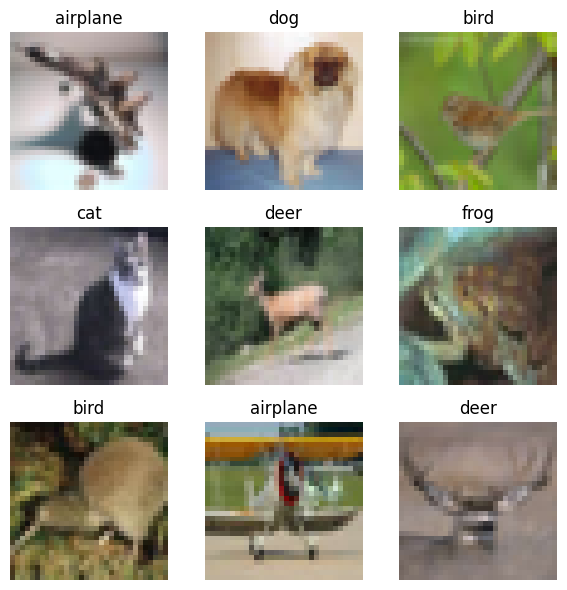

In [ ]:
import matplotlib.pyplot as plt
import random
import torch

def show_samples(dataset, n=9):
    fig, axes = plt.subplots(3, 3, figsize=(6,6))

    for ax in axes.flatten():
        idx = random.randint(0, len(dataset)-1)
        img, label = dataset[idx]

        # Unnormalize
        img = img * 0.5 + 0.5
        img = img.permute(1,2,0)

        ax.imshow(img)
        ax.set_title(dataset.classes[label])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_samples(trainset)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ToyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global average pool
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
model = ToyCNN(num_classes=10).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss() # TODOl CHANGE TO SINKHORN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def train_epoch(model, loader, criterion=criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion=criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


In [ ]:
epochs = 10

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, test_loader)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-"*40)

Epoch 1/10
Train Loss: 1.1972 | Train Acc: 0.5690
Val   Loss: 1.2025 | Val   Acc: 0.5783
----------------------------------------
Epoch 2/10
Train Loss: 0.8057 | Train Acc: 0.7172
Val   Loss: 0.7695 | Val   Acc: 0.7239
----------------------------------------
Epoch 3/10
Train Loss: 0.6418 | Train Acc: 0.7762
Val   Loss: 1.0453 | Val   Acc: 0.6627
----------------------------------------
Epoch 4/10
Train Loss: 0.5417 | Train Acc: 0.8126
Val   Loss: 0.6022 | Val   Acc: 0.7875
----------------------------------------
Epoch 5/10
Train Loss: 0.4666 | Train Acc: 0.8388
Val   Loss: 0.7105 | Val   Acc: 0.7524
----------------------------------------
Epoch 6/10
Train Loss: 0.4088 | Train Acc: 0.8580
Val   Loss: 0.5904 | Val   Acc: 0.8039
----------------------------------------
Epoch 7/10
Train Loss: 0.3592 | Train Acc: 0.8754
Val   Loss: 0.6217 | Val   Acc: 0.7959
----------------------------------------
Epoch 8/10
Train Loss: 0.3103 | Train Acc: 0.8924
Val   Loss: 0.6562 | Val   Acc: 0.7868
-

In [ ]:
class_correct = [0] * 10
class_total = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for i in range(len(labels)):
            label = labels[i]
            class_total[label] += 1
            if preds[i] == label:
                class_correct[label] += 1

print("per class accuracy (cross entropy loss):")
for i in range(10):
    print(f"{trainset.classes[i]}: {class_correct[i] / class_total[i]:.3f}")

per class accuracy (cross entropy loss):
airplane: 0.814
automobile: 0.910
bird: 0.867
cat: 0.600
deer: 0.843
dog: 0.691
frog: 0.874
horse: 0.819
ship: 0.924
truck: 0.806


Let's implement our Sinkhorn loss function:

In [ ]:
# =====================================
# LOG-DOMAIN SINKHORN + HYBRID LOSS
# =====================================

import torch
import torch.nn.functional as F

# -------------------------------------
# Build class cost matrix
# -------------------------------------

def build_cost_matrix(K, device):
    idx = torch.arange(K, device=device).float()
    C = torch.abs(idx[:, None] - idx[None, :])
    return C


# -------------------------------------
# Log-domain Sinkhorn
# -------------------------------------

def log_sinkhorn_loss(logits, labels, C, epsilon=0.5, n_iters=30):

    B, K = logits.shape
    device = logits.device

    # Predicted probabilities
    p = F.softmax(logits, dim=1)

    # One-hot labels (smoothed)
    y = torch.zeros_like(p)
    y.scatter_(1, labels.unsqueeze(1), 1.0)
    y = y + 1e-8
    y = y / y.sum(dim=1, keepdim=True)

    log_r = torch.log(p + 1e-8)
    log_c = torch.log(y + 1e-8)

    log_K = -C / epsilon

    u = torch.zeros_like(log_r)
    v = torch.zeros_like(log_c)

    for _ in range(n_iters):
        u = log_r - torch.logsumexp(
            log_K.unsqueeze(0) + v.unsqueeze(1),
            dim=2
        )

        v = log_c - torch.logsumexp(
            log_K.unsqueeze(0) + u.unsqueeze(2),
            dim=1
        )

    log_P = (
        u.unsqueeze(2)
        + log_K.unsqueeze(0)
        + v.unsqueeze(1)
    )

    P = torch.exp(log_P)

    loss = torch.sum(P * C.unsqueeze(0), dim=(1,2))

    return loss.mean()


# =====================================
# TRAINING SETUP
# =====================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ToyCNN(num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

C = build_cost_matrix(10, device)

alpha = 0.1  # weight of Sinkhorn term


def hybrid_loss(outputs, labels):
    ce = F.cross_entropy(outputs, labels)
    ot = log_sinkhorn_loss(outputs, labels, C,
                           epsilon=0.5,
                           n_iters=30)
    return ce + alpha * ot


# =====================================
# TRAIN / EVAL FUNCTIONS
# =====================================

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = hybrid_loss(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = hybrid_loss(outputs, labels)

            total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


# =====================================
# RUN TRAINING
# =====================================

epochs = 10

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, test_loader)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-"*40)

Epoch 1/10
Train Loss: 1.4102 | Train Acc: 0.5634
Val   Loss: 1.4733 | Val   Acc: 0.5668
----------------------------------------
Epoch 2/10
Train Loss: 0.9402 | Train Acc: 0.7146
Val   Loss: 1.1632 | Val   Acc: 0.6506
----------------------------------------
Epoch 3/10
Train Loss: 0.7478 | Train Acc: 0.7738
Val   Loss: 0.9523 | Val   Acc: 0.7204
----------------------------------------
Epoch 4/10
Train Loss: 0.6303 | Train Acc: 0.8120
Val   Loss: 0.8614 | Val   Acc: 0.7448
----------------------------------------
Epoch 5/10
Train Loss: 0.5381 | Train Acc: 0.8385
Val   Loss: 0.8727 | Val   Acc: 0.7346
----------------------------------------
Epoch 6/10
Train Loss: 0.4785 | Train Acc: 0.8582
Val   Loss: 0.6895 | Val   Acc: 0.7956
----------------------------------------
Epoch 7/10
Train Loss: 0.4103 | Train Acc: 0.8780
Val   Loss: 0.7258 | Val   Acc: 0.7994
----------------------------------------
Epoch 8/10
Train Loss: 0.3599 | Train Acc: 0.8927
Val   Loss: 0.7116 | Val   Acc: 0.8028
-

In [ ]:
num_classes = 10

class_correct = torch.zeros(num_classes)
class_total = torch.zeros(num_classes)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for label, pred in zip(labels, preds):
            class_total[label.item()] += 1
            if pred == label:
                class_correct[label.item()] += 1

print("Per class accuracy (Sinkhorn-trained model):")
for i in range(num_classes):
    acc = class_correct[i] / class_total[i]
    print(f"{trainset.classes[i]}: {acc:.3f}")

Per class accuracy (Sinkhorn-trained model):
airplane: 0.937
automobile: 0.898
bird: 0.706
cat: 0.796
deer: 0.715
dog: 0.425
frog: 0.907
horse: 0.638
ship: 0.902
truck: 0.894


# Let's think about this example, you have a time series over some time horizon $T$, $(high = p_i, medium = p_j, low = p_k), \ldots$. How to encode that fact that high is further than low that it is to medium.

TODO: Read COT-GAN